In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import stumpy

plt.style.use('default')
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

In [37]:
# Загружаем НЕПРЕРЫВНЫЕ данные со всеми фичами (Layer 1 Pipeline)
# Здесь нет никакого влияния generic_strategy.py!
df = pd.read_parquet("../data/processed/gbpusd_with_all_features.parquet")

# Убедимся, что индекс - это время
if 'timestamp' in df.columns:
    df.set_index('timestamp', inplace=True)
elif df.index.name != 'timestamp':
    df.index = pd.to_datetime(df.index)

df_subset = df.loc['2020-01-01':'2026-02-27'].copy()

# Выбираем фичу для поиска (например, волатильность)
target_feature = 'dist_to_pdh'
T_feature = df_subset[target_feature].values
T_price = df_subset['close'].values 

print(f"Loaded CONTINUOUS data: {len(T_feature)} bars. No strategy bias!")

Loaded CONTINUOUS data: 154360 bars. No strategy bias!


In [ ]:
m = 16
print(f"Calculating Matrix Profile for m={m} on '{target_feature}'...")

# Считаем профиль по выбранной фиче, а не по цене!
matrix_profile = stumpy.stump(T_feature, m)
mp = matrix_profile[:, 0]

print("Matrix Profile calculation complete!")

Calculating Matrix Profile for m=48 on 'dist_to_pdh'...
Matrix Profile calculation complete!


In [50]:
# Параметры фильтрации
TOP_MOTIFS = 3
DISTANCE_THRESHOLD = 2.0 # (Это ваш min_distance фильтр: дистанция ДОЛЖНА БЫТЬ < 2.0)
MAX_MATCHES = 99999 # Максимальное количество совпадений для одного мотива

# Функция stumpy.motifs автоматически находит самые популярные паттерны
# и собирает их соседей с учетом порога
distances, indices = stumpy.motifs(
    T_feature, 
    mp, 
    max_motifs=TOP_MOTIFS, 
    max_matches=MAX_MATCHES, 
    max_distance=DISTANCE_THRESHOLD
)

# distances[i] содержит дистанции для i-го мотива
# indices[i] содержит индексы (где этот мотив встретился в данных)

print(f"Extracted Top-{TOP_MOTIFS} Motifs with distance < {DISTANCE_THRESHOLD}")
for i in range(TOP_MOTIFS):
    # Убираем NaN (если совпадений меньше чем MAX_MATCHES)
    valid_matches = [idx for idx in indices[i] if not np.isnan(idx)]
    print(f"Motif {i+1}: Found {len(valid_matches)} exact matches.")

Extracted Top-3 Motifs with distance < 2.0
Motif 1: Found 274 exact matches.
Motif 2: Found 274 exact matches.
Motif 3: Found 274 exact matches.


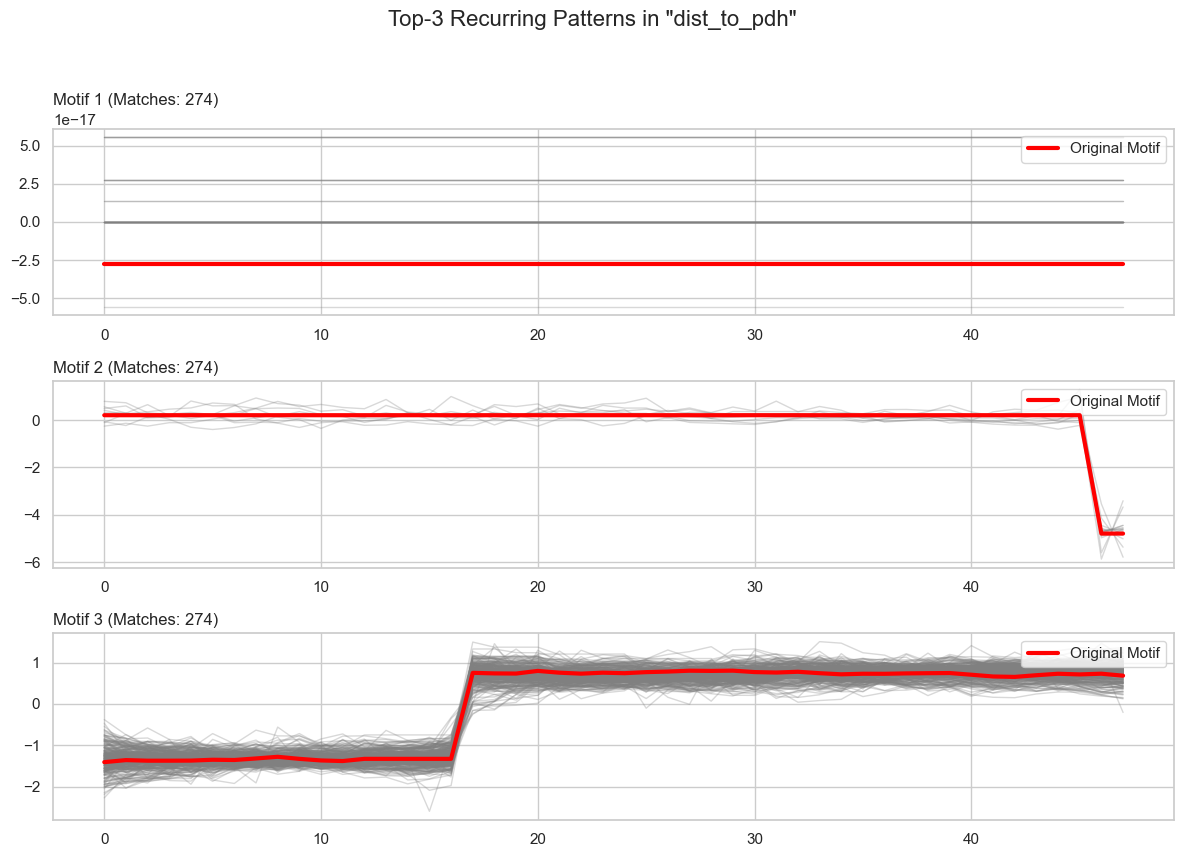

In [51]:
fig, axs = plt.subplots(TOP_MOTIFS, 1, figsize=(12, 3 * TOP_MOTIFS), sharex=False)
plt.suptitle(f'Top-{TOP_MOTIFS} Recurring Patterns in "{target_feature}"', fontsize=16)

for i in range(TOP_MOTIFS):
    valid_indices = [int(idx) for idx in indices[i] if not np.isnan(idx)]
    
    if len(valid_indices) == 0:
        continue
        
    ax = axs[i]
    ax.set_title(f"Motif {i+1} (Matches: {len(valid_indices)})", loc='left')
    
    # Рисуем все найденные совпадения для данного мотива
    for idx in valid_indices:
        pattern = T_feature[idx : idx + m]
        # Нормализуем для красоты сравнения
        pattern_norm = stumpy.core.z_norm(pattern)
        
        # Оригинал выделяем красным, совпадения - серым
        if idx == valid_indices[0]:
            ax.plot(pattern_norm, color='red', linewidth=3, zorder=10, label='Original Motif')
        else:
            ax.plot(pattern_norm, color='gray', alpha=0.3, linewidth=1)
            
    ax.legend(loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

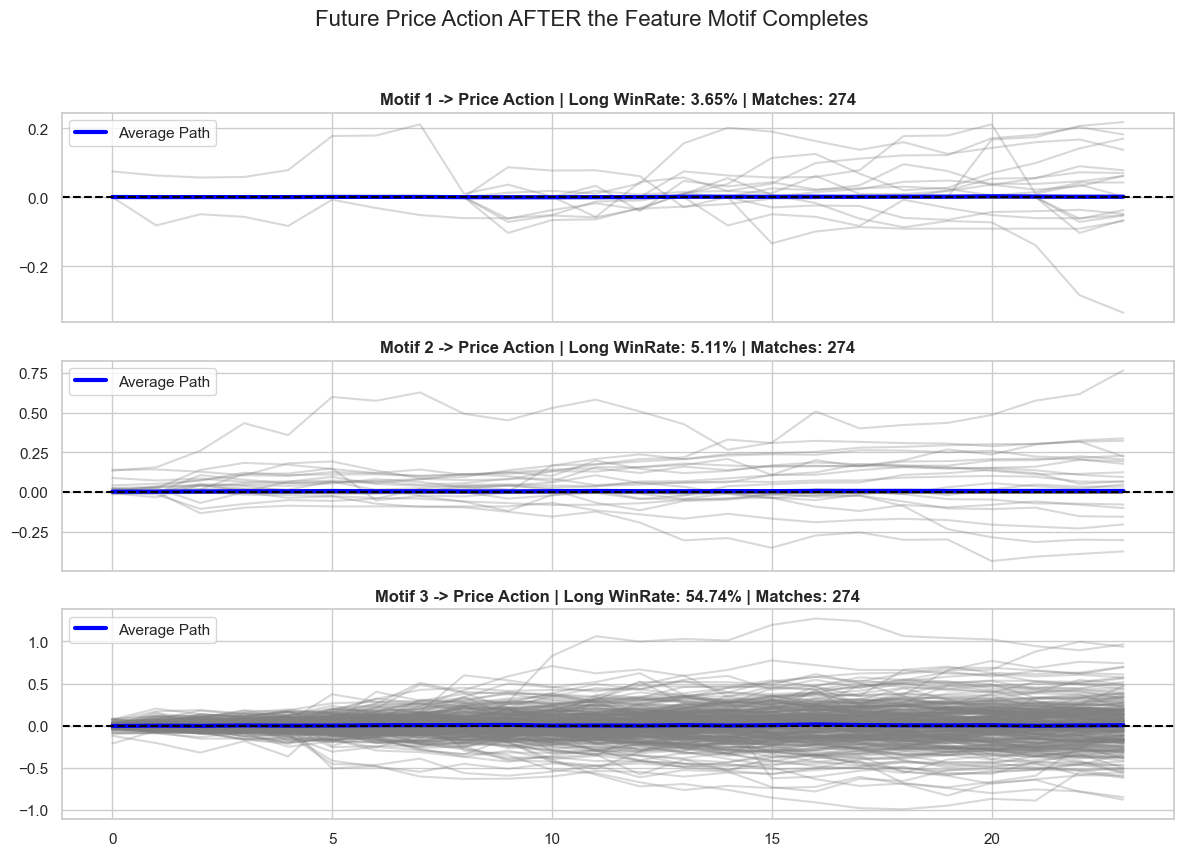

In [52]:
forward_horizon = 24 # Смотрим на 6 часов вперед

fig, axs = plt.subplots(TOP_MOTIFS, 1, figsize=(12, 3 * TOP_MOTIFS), sharex=True)
plt.suptitle('Future Price Action AFTER the Feature Motif Completes', fontsize=16)

for i in range(TOP_MOTIFS):
    valid_indices = [int(idx) for idx in indices[i] if not np.isnan(idx)]
    ax = axs[i]
    returns = []
    
    if len(valid_indices) < 2:
        ax.set_title(f"Motif {i+1}: Not enough data")
        continue
        
    for idx in valid_indices:
        # Индекс КОНЦА мотива
        end_idx = idx + m
        if end_idx + forward_horizon < len(T_price):
            # Извлекаем будущую цену
            future_price = T_price[end_idx : end_idx + forward_horizon]
            entry_price = T_price[end_idx - 1]
            
            # % изменения цены
            pct_change = (future_price - entry_price) / entry_price * 100
            returns.append(pct_change[-1])
            
            ax.plot(pct_change, color='gray', alpha=0.3)
    
    if returns:
        avg_path = np.mean([ 
            (T_price[idx+m : idx+m+forward_horizon] - T_price[idx+m-1]) / T_price[idx+m-1] * 100 
            for idx in valid_indices if idx+m+forward_horizon < len(T_price)
        ], axis=0)
        
        ax.plot(avg_path, color='blue', linewidth=3, label='Average Path')
        
        win_rate_long = len([r for r in returns if r > 0]) / len(returns)
        ax.set_title(f"Motif {i+1} -> Price Action | Long WinRate: {win_rate_long:.2%} | Matches: {len(returns)}", fontweight='bold')
        ax.axhline(0, color='black', linestyle='--')
        ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()